In [21]:
import numpy as np
import cv2
import os
from PIL import Image, ImageDraw
from skimage.feature import graycomatrix, graycoprops, hog
from skimage.color import rgb2gray
# No additional import is needed here.
# train_test_split is imported below.
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.utils import shuffle
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# _________________________________________________ Test Stage _____________________________________________
# _________________________________________Load Feature Extraction Vectores ________________________________
# ____________________________________ hog or glcm or orb , vgg , yolo , resnet ____________________________


In [22]:
# load Feature Extraction Vectors (hog, glcm, orb, vgg, yolo, squeezenet, resnet, ML, DL, ALL)


import numpy as np




# Set feature_type to one of: 'all', 'ml', 'dl', 'hog', 'glcm', 'orb', 'vgg', 'yolo', 'squeezenet', 'resnet'


feature_type = 'ml'  # Change to 'all', 'ml', 'dl', 'hog', 'glcm', 'orb', 'vgg', 'yolo', 'squeezenet', 'resnet' as needed




features_array = None




if feature_type == 'all':


    df = pd.read_csv('final_Features/all_features_array.csv')


    print("Loaded ALL features (ML + DL).")


elif feature_type == 'ml':


    df = pd.read_csv('final_Features/ml_features_array.csv')


    print("Loaded ML features.")


elif feature_type == 'dl':


    df = pd.read_csv('final_Features/dl_features_array.csv')


    print("Loaded DL features.")


elif feature_type == 'hog':


    df = pd.read_csv('final_Features/hog_features_array.csv')


    print("Loaded HOG features.")


elif feature_type == 'glcm':


    df = pd.read_csv('final_Features/glcm_features_array.csv')


    print("Loaded GLCM features.")


elif feature_type == 'orb':


    df = pd.read_csv('final_Features/orb_features_array.csv')


    print("Loaded ORB features.")


elif feature_type == 'vgg':


    df = pd.read_csv('final_Features/vgg_features_array.csv')


    print("Loaded VGG features.")


elif feature_type == 'resnet':


    df = pd.read_csv('final_Features/resnet_features_array.csv')


    print("Loaded ResNet features.")


elif feature_type == 'squeezenet':


    df = pd.read_csv('final_Features/squeezenet_features_array.csv')


    print("Loaded squeezenet features.")


elif feature_type == 'yolo':


    df = pd.read_csv('final_Features/yolo_features_array.csv')


    print("Loaded YOLO features.")


else:


    raise ValueError("Invalid feature_type. Choose from 'all', 'ml', 'dl', 'hog', 'glcm', 'orb', 'vgg', 'yolo', 'squeezenet', 'resnet'.")




# Keep only numeric feature columns; some exported files contain a duplicated text label column.


feature_columns = df.drop(columns='label').select_dtypes(include=np.number).columns


features_array = df[feature_columns].to_numpy(dtype=np.float64)


labels_array = df['label'].to_numpy()




print('Features shape:', features_array.shape)


print('Labels shape:', labels_array.shape)


print(f"------++++++++ Load Feature Extraction Vectors is Done :- {feature_type} +++++++++-------------")

Loaded ML features.


KeyError: "['label'] not found in axis"

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

def split_train_test(data, train_size=0.8, random_state=42):
    """Split rows into stratified train and test partitions."""
    if len(data) < 2:
        raise ValueError("At least two rows are required for a train/test split.")

    if isinstance(train_size, float):
        if not 0 < train_size < 1:
            raise ValueError("A float train_size must be between 0 and 1.")
    elif not 0 < train_size < len(data):
        raise ValueError("An integer train_size must leave at least one test row.")

    indices = np.arange(len(data))
    train_indices, test_indices = train_test_split(
        indices,
        train_size=train_size,
        stratify=data[:, -1],
        random_state=random_state
    )

    train = data[train_indices]
    test = data[test_indices]
    return train[:, :-1], train[:, -1], test[:, :-1], test[:, -1]

In [ ]:
train_size = int(len(features_array) * 0.8)


X_train, X_test, y_train, y_test = train_test_split(


    features_array,


    labels_array,


    train_size=train_size,


    stratify=labels_array,


    random_state=42


)




if len(X_train) == 0 or len(X_test) == 0:


    raise ValueError(


        f"The split produced an empty partition: train={len(X_train)}, test={len(X_test)}."


    )




print("X_train shape:", X_train.shape)


print("X_test shape:", X_test.shape)


print("y_train shape:", y_train.shape)


print("y_test shape:", y_test.shape)


print("Non-numeric feature values:", X_train.dtype.kind not in 'fiu')

X_train shape: (5112, 512)
X_test shape: (1278, 512)
y_train shape: (5112,)
y_test shape: (1278,)
Non-numeric feature values: False


In [ ]:
from imblearn.over_sampling import RandomOverSampler

# Oversample the features_array and labels to balance the classes
oversample = RandomOverSampler(sampling_strategy='not majority', random_state=42)
X_train2, y_train2 = oversample.fit_resample(X_train, y_train)

print("Original class distribution:", Counter(y_train))
print("Resampled class distribution:", Counter(y_train2))
print("Resampled features_array shape:", X_train2.shape)

Original class distribution: Counter({'osteoporosis': 3059, 'normal': 2053})
Resampled class distribution: Counter({'osteoporosis': 3059, 'normal': 3059})
Resampled features_array shape: (6118, 512)


In [ ]:
# === إصلاح شامل لمشكلة الأنواع ===
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# 1. نقوم بتدريب المشفر على y_train2 (بعد التضخيم) لأنه يحتوي على جميع الأصناف
le.fit(y_train2)

# 2. نقوم بتحويل جميع متغيرات التسميات المستخدمة في الكود
# (هذا هو السطر الذي كان مفقوداً ويسبب الخطأ)
y_train = le.transform(y_train)

# تحويل المتغيرات الأخرى
y_train2 = le.transform(y_train2)
y_test = le.transform(y_test)

print("تم تحويل جميع المتغيرات (y_train, y_train2, y_test) إلى أرقام بنجاح.")
print(f"الأصناف: {le.classes_}")

تم تحويل جميع المتغيرات (y_train, y_train2, y_test) إلى أرقام بنجاح.
الأصناف: ['normal' 'osteoporosis']



Evaluating RandomForest
Training Accuracy: 0.9892
Test Accuracy: 0.9343


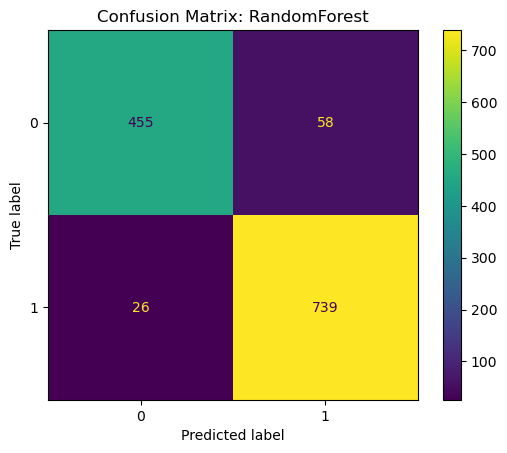

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       513
           1       0.93      0.97      0.95       765

    accuracy                           0.93      1278
   macro avg       0.94      0.93      0.93      1278
weighted avg       0.93      0.93      0.93      1278


Evaluating ExtraTrees
Training Accuracy: 0.9892
Test Accuracy: 0.9413


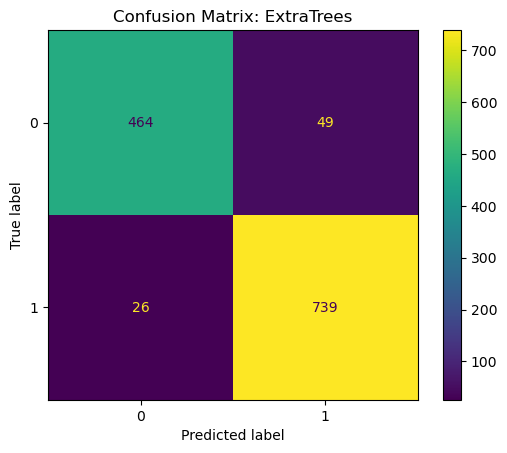

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93       513
           1       0.94      0.97      0.95       765

    accuracy                           0.94      1278
   macro avg       0.94      0.94      0.94      1278
weighted avg       0.94      0.94      0.94      1278


Evaluating LogisticRegression
Training Accuracy: 0.9366
Test Accuracy: 0.8865


c:\Users\iqmah\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


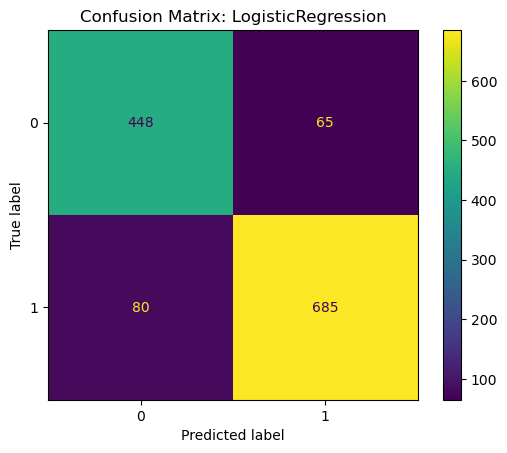

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       513
           1       0.91      0.90      0.90       765

    accuracy                           0.89      1278
   macro avg       0.88      0.88      0.88      1278
weighted avg       0.89      0.89      0.89      1278


Evaluating XGBoost
Training Accuracy: 0.9892
Test Accuracy: 0.9484


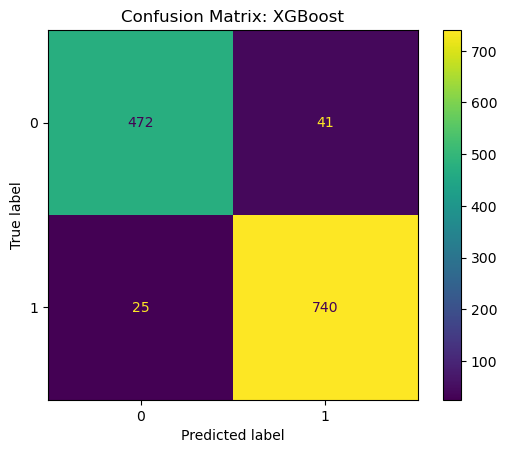

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       513
           1       0.95      0.97      0.96       765

    accuracy                           0.95      1278
   macro avg       0.95      0.94      0.95      1278
weighted avg       0.95      0.95      0.95      1278


Evaluating MLPClassifier
Training Accuracy: 0.9796
Test Accuracy: 0.9491


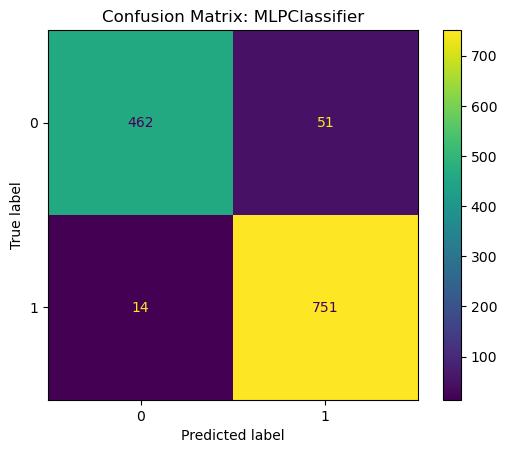

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       513
           1       0.94      0.98      0.96       765

    accuracy                           0.95      1278
   macro avg       0.95      0.94      0.95      1278
weighted avg       0.95      0.95      0.95      1278


Evaluating LDA
Training Accuracy: 0.9183
Test Accuracy: 0.8826


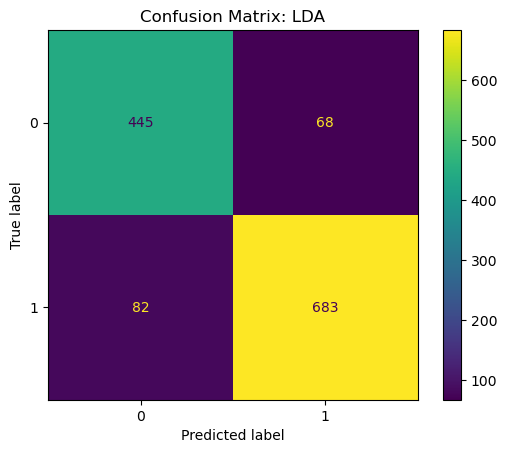

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       513
           1       0.91      0.89      0.90       765

    accuracy                           0.88      1278
   macro avg       0.88      0.88      0.88      1278
weighted avg       0.88      0.88      0.88      1278


Evaluating LinearSVC
Training Accuracy: 0.9403
Test Accuracy: 0.8897


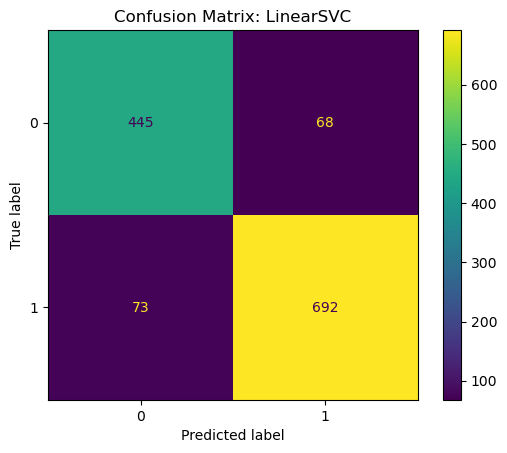

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       513
           1       0.91      0.90      0.91       765

    accuracy                           0.89      1278
   macro avg       0.88      0.89      0.89      1278
weighted avg       0.89      0.89      0.89      1278


Evaluating LightGBM
Training Accuracy: 0.9890
Test Accuracy: 0.9452


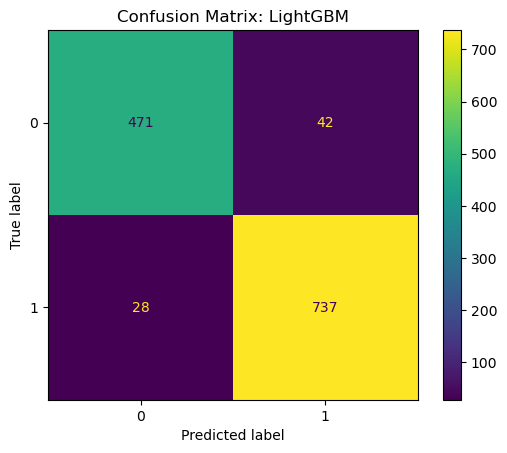

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       513
           1       0.95      0.96      0.95       765

    accuracy                           0.95      1278
   macro avg       0.94      0.94      0.94      1278
weighted avg       0.95      0.95      0.95      1278


Evaluating HistGradientBoosting
Training Accuracy: 0.9892
Test Accuracy: 0.9413


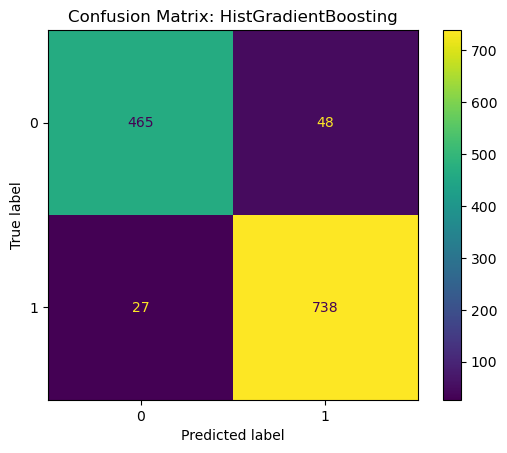

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       513
           1       0.94      0.96      0.95       765

    accuracy                           0.94      1278
   macro avg       0.94      0.94      0.94      1278
weighted avg       0.94      0.94      0.94      1278


Evaluating RidgeClassifier
Training Accuracy: 0.9186
Test Accuracy: 0.8818


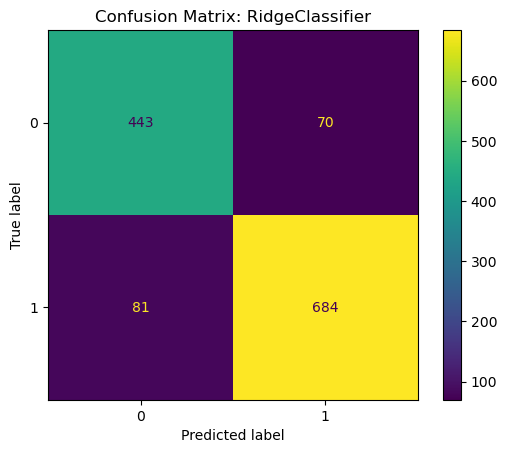

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.85       513
           1       0.91      0.89      0.90       765

    accuracy                           0.88      1278
   macro avg       0.88      0.88      0.88      1278
weighted avg       0.88      0.88      0.88      1278


Average Metrics for Each Classifier:
             Classifier  Accuracy  Precision    Recall        F1
0          RandomForest  0.934272   0.936587  0.926476  0.930858
1            ExtraTrees  0.941315   0.942378  0.935248  0.938465
2    LogisticRegression  0.886541   0.880909  0.884360  0.882501
3               XGBoost  0.948357   0.948601  0.943699  0.945981
4         MLPClassifier  0.949139   0.953499  0.941142  0.946398
5                   LDA  0.882629   0.876928  0.880128  0.878412
6             LinearSVC  0.889671   0.884800  0.886011  0.885390
7              LightGBM  0.945227   0.944986  0.940764  0.942747
8  HistGradientBoosting  0.

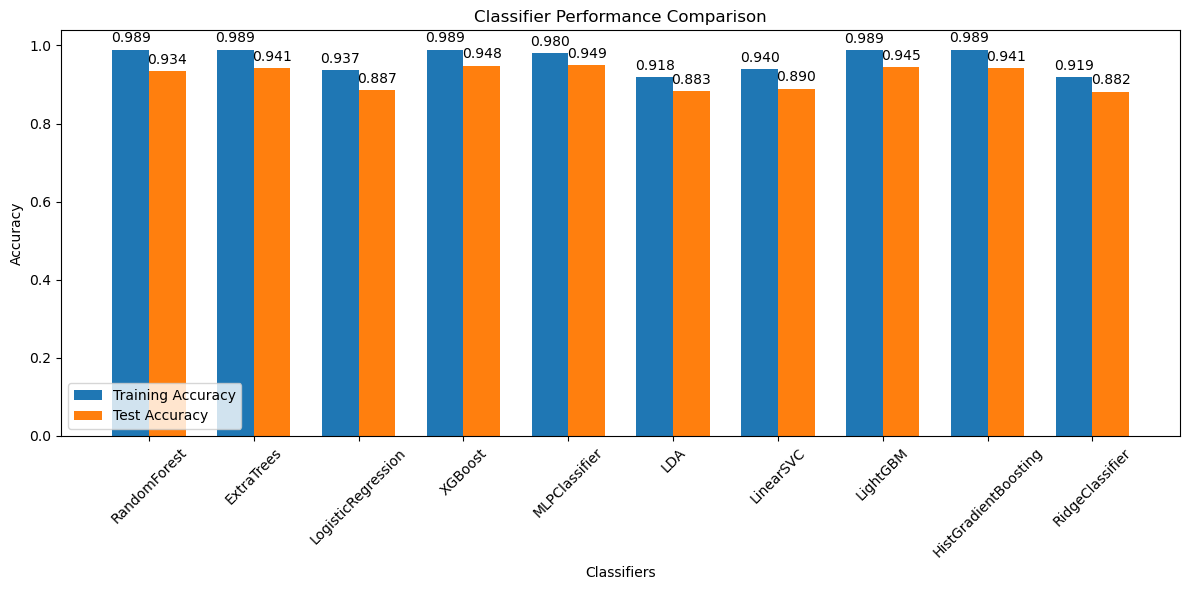

In [ ]:
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, BaggingClassifier, VotingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier, SGDClassifier,
    PassiveAggressiveClassifier, Perceptron
)
from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from collections import Counter
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("Warning: CatBoost not installed. Run '!pip install catboost'")

most_frequent_label = Counter(y_train).most_common(1)[0][0]

classifiers = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'MLPClassifier': MLPClassifier(random_state=42, max_iter=500),
    'LDA': LinearDiscriminantAnalysis(),
    'LinearSVC': LinearSVC(random_state=42, max_iter=1000),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(max_iter=100, random_state=42),
    'RidgeClassifier': RidgeClassifier(random_state=42),
}

results = {}
metrics_table = []
for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Evaluating {name}")
    print(f"{'='*50}")
    clf.fit(X_train2, y_train2)
    train_acc = clf.score(X_train2, y_train2)
    test_acc = clf.score(X_test, y_test)
    y_pred = clf.predict(X_test)
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot()
    plt.title(f"Confusion Matrix: {name}")
    plt.show()
    print('Classification Report:')
    print(classification_report(y_test, y_pred, zero_division=0))
    metrics_table.append({
        'Classifier': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1': f1_score(y_test, y_pred, average='macro', zero_division=0)
    })
    results[name] = {'train_accuracy': train_acc, 'test_accuracy': test_acc}

metrics_df = pd.DataFrame(metrics_table)
print("\nAverage Metrics for Each Classifier:")
print(metrics_df)

names = list(results.keys())
train_accuracies = [results[name]['train_accuracy'] for name in names]
test_accuracies = [results[name]['test_accuracy'] for name in names]
x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width / 2, train_accuracies, width, label='Training Accuracy')
rects2 = ax.bar(x + width / 2, test_accuracies, width, label='Test Accuracy')
ax.set_xlabel('Classifiers')
ax.set_ylabel('Accuracy')
ax.set_title('Classifier Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45)
ax.legend()

for rects in (rects1, rects2):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f'{height:.3f}',
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

In [ ]:
#%pip install lightgbm